In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

In [2]:
def change_log_bins(old_bins, old_histo, new_nbins):
    new_bins = np.logspace(np.log10(old_bins[0]), np.log10(old_bins[-1]), new_nbins+1)
    new_histo = np.zeros(new_nbins)
    old_bins_center = (old_bins[:-1] + old_bins[1:])/2

    for i in range(new_nbins - 1): #Take the lin histo and turn it into a log histo
        # Trouver les bins linéaires qui chevauchent le bin logarithmique courant
        overlap = (old_bins_center >= new_bins[i]) & (old_bins_center < new_bins[i + 1])
        # Ajouter les comptages de ces bins linéaires au bin logarithmique
        if len(old_histo[overlap])!=0:
            new_histo[i] = np.sum(old_histo[overlap])/len(old_histo[overlap])
            
    return new_bins, new_histo
        

In [ ]:
data = np.loadtxt("/data1/DATA_Duplat/Brut/Patch_distribution/Pa2n1/patch_ava_histo.txt").T

NCURVES = len(data)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

bins = np.logspace(np.log10(1), np.log10(256*256), 101)
bins_center = (bins[:-1] + bins[1:])/2
nb_new_bins = 25

start = 2
stop = 13


with plt.style.context(spstyle.get_style('thesis')):
    fig, (ax, ax2) = plt.subplots(1, 2, figsize = (7.2,2.8))
    for i, line in enumerate(data[10:]):
        new_bins, new_line = change_log_bins(bins, line, nb_new_bins)
        bin_diff = np.diff(new_bins)
        bins_center = (new_bins[:-1] + new_bins[1:])/2
        mask = new_line!=0
        f_line = new_line[mask]
        f_bins_center = bins_center[mask]
        f_bin_diff = bin_diff[mask]
        
        norm_line = f_line/(np.sum(f_line)*f_bin_diff)
        
        if i == 50:
            popt, pcov = curve_fit(powerlaw2, np.log(f_bins_center[start:stop]), np.log(norm_line[start:stop]), p0 = [0.5, 1.6], maxfev = 1000)
            tau = -popt[1]
            yfit = np.exp(powerlaw2(np.log(f_bins_center[start:stop]), *popt))
            ax2.scatter(i+10, tau)
            ax.plot(f_bins_center[start:stop], yfit, ls = '--', c = 'r', zorder = 100)
            
        ax.plot(f_bins_center, norm_line, c = colors[i])
        
        
    ax.set_xscale('log')
    ax.set_yscale('log')
    plt.show()

/tmp/ipykernel_2230239/673386260.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_2230239/673386260.py:35: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(Tnu[j], tau, c = colors[j])


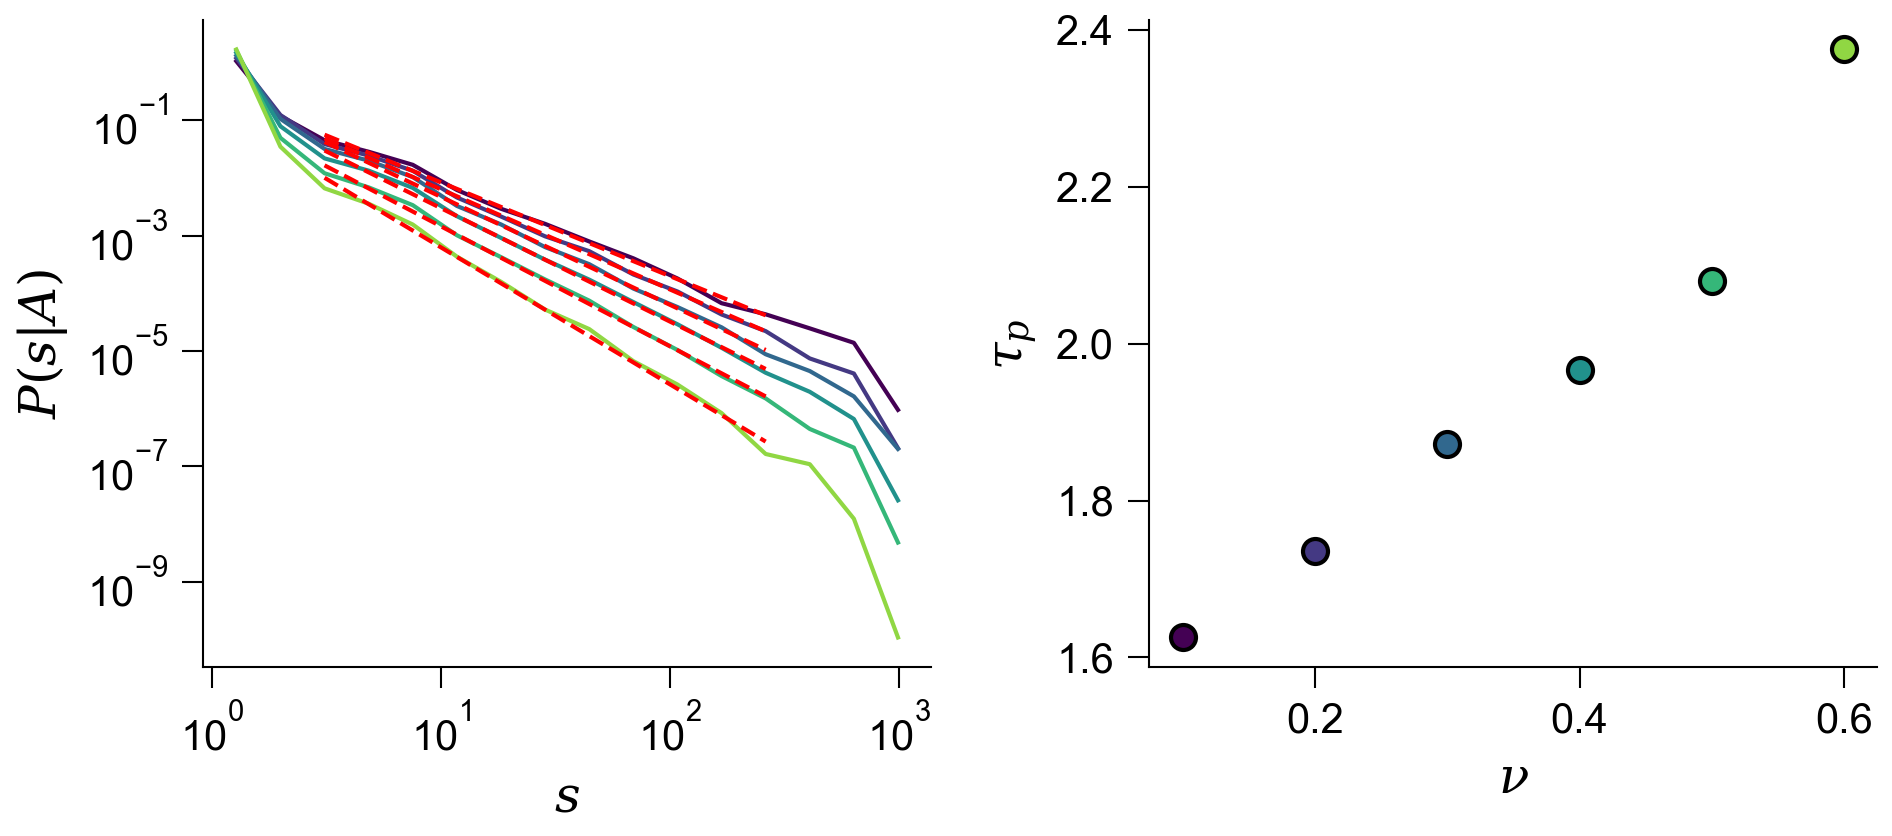

In [22]:
Tfilepath = ["/data1/DATA_Duplat/Brut/Patch_distribution/Pa2n{}/patch_ava_histo.txt".format(i) for i in range(1,7)]
Tnu = [0.1,0.2,0.3,0.4,0.5,0.6]

NCURVES = len(Tnu)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

bins = np.logspace(np.log10(1), np.log10(256*256), 101)
bins_center = (bins[:-1] + bins[1:])/2
nb_new_bins = 25

start = 2
stop = 13


with plt.style.context(spstyle.get_style('thesis')):
    fig, (ax, ax2) = plt.subplots(1, 2, figsize = (7.2,2.8))
    fig.subplots_adjust(wspace = 0.3)
    for j, file in enumerate(Tfilepath):
        data = np.loadtxt(file).T
        for i, line in enumerate(data[10:]):
            new_bins, new_line = change_log_bins(bins, line, nb_new_bins)
            bin_diff = np.diff(new_bins)
            bins_center = (new_bins[:-1] + new_bins[1:])/2
            mask = new_line!=0
            f_line = new_line[mask]
            f_bins_center = bins_center[mask]
            f_bin_diff = bin_diff[mask]
            
            norm_line = f_line/(np.sum(f_line)*f_bin_diff)
            
            if i == 50:
                popt, pcov = curve_fit(powerlaw2, np.log(f_bins_center[start:stop]), np.log(norm_line[start:stop]), p0 = [0.5, 1.6], maxfev = 1000)
                tau = -popt[1]
                yfit = np.exp(powerlaw2(np.log(f_bins_center[start:stop]), *popt))
                ax2.scatter(Tnu[j], tau, c = colors[j])
                ax.plot(f_bins_center[start:stop], yfit, ls = '--', c = 'r', zorder = 100)
                
                ax.plot(f_bins_center, norm_line, c = colors[j])
        
    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$P(s|A)$")
    ax2.set_xlabel(r"$\nu$")
    ax2.set_ylabel(r"$\tau _p$")
    ax.set_xscale('log')
    ax.set_yscale('log')
    plt.show()

/tmp/ipykernel_2230239/2969181813.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


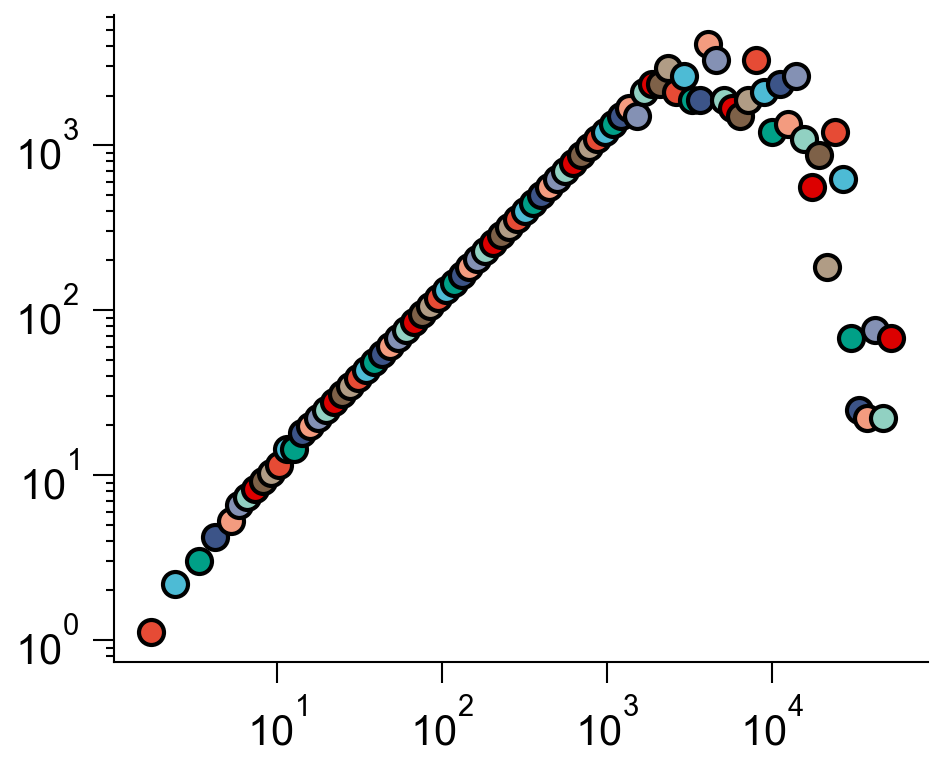

In [4]:
data = np.loadtxt("/data1/DATA_Duplat/Brut/Test/Te62n1/patch_ava_histo.txt").T
NCURVES = len(data)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

bins = np.logspace(np.log10(1), np.log10(256*256), 101)
inv_bins = bins[::-1]
bins_center = (bins[:-1] + bins[1:])/2
nb_new_bins = 15

start = 1
stop = 8
with plt.style.context(spstyle.get_style('thesis')):
    fig, ax = plt.subplots(1, 1, figsize = (3.5,2.8))
    for i, line in enumerate(data):
        if np.sum(line) !=0:
            inv_line = line[::-1]
        
            first_zero = np.where(inv_line != 0)[0][0]
            ax.scatter(bins[i-1], inv_bins[first_zero])
        
    ax.set_xscale('log')
    ax.set_yscale('log')
    plt.show()